Mount Google Drive

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Data

In [42]:
import pandas as pd

# Structured data
admissions = pd.read_csv('/content/drive/MyDrive/mimic_demo/ADMISSIONS.csv')
chartevents = pd.read_csv('/content/drive/MyDrive/mimic_demo/CHARTEVENTS.csv')
labevents = pd.read_csv('/content/drive/MyDrive/mimic_demo/LABEVENTS.csv')

# Unstructured data
notes = pd.read_csv('/content/drive/MyDrive/mimic_demo/NOTEEVENTS.csv')

# Quick check
print("Admissions columns:", admissions.columns)
print("Chartevents columns:", chartevents.columns)
print("Labevents columns:", labevents.columns)
print("Notes columns:", notes.columns)

/tmp/ipykernel_786/3682139050.py:5: DtypeWarning: Columns (8,10,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  chartevents = pd.read_csv('/content/drive/MyDrive/mimic_demo/CHARTEVENTS.csv')


Admissions columns: Index(['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime',
       'deathtime', 'admission_type', 'admission_location',
       'discharge_location', 'insurance', 'language', 'religion',
       'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis',
       'hospital_expire_flag', 'has_chartevents_data'],
      dtype='object')
Chartevents columns: Index(['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'itemid', 'charttime',
       'storetime', 'cgid', 'value', 'valuenum', 'valueuom', 'warning',
       'error', 'resultstatus', 'stopped'],
      dtype='object')
Labevents columns: Index(['row_id', 'subject_id', 'hadm_id', 'itemid', 'charttime', 'value',
       'valuenum', 'valueuom', 'flag'],
      dtype='object')
Notes columns: Index(['row_id', 'subject_id', 'hadm_id', 'chartdate', 'charttime',
       'storetime', 'category', 'description', 'cgid', 'iserror', 'text'],
      dtype='object')


Preprocessing Structured Data

In [43]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Fill missing values
chartevents.fillna(0, inplace=True)
labevents.fillna(0, inplace=True)

# Normalize numeric features
scaler = MinMaxScaler()

# Select numeric columns only for scaling
chartevents_scaled = scaler.fit_transform(chartevents.select_dtypes(include=[np.number]))
labevents_scaled = scaler.fit_transform(labevents.select_dtypes(include=[np.number]))

print("Chartevents shape:", chartevents_scaled.shape)
print("Labevents shape:", labevents_scaled.shape)

Chartevents shape: (758355, 9)
Labevents shape: (76074, 5)


In [44]:
!pip install gensim

Preprocessing Unstructured Data

In [45]:
import nltk
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

nltk.download('punkt')

# Make sure text column exists and is clean
notes = notes[~notes['text'].isnull()]
notes['text'] = notes['text'].astype(str).str.lower()

# Tokenize and tag notes
tagged_notes = [
    TaggedDocument(words=nltk.word_tokenize(text), tags=[str(i)])
    for i, text in enumerate(notes['text'])
]

print("Tagged notes ready. Doc2Vec model can be trained later if needed.")

Tagged notes ready. Doc2Vec model can be trained later if needed.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Aggregate Data

In [46]:

# For chartevents
chartevents_numeric = chartevents.select_dtypes(include=[np.number])
chartevents_numeric['hadm_id'] = chartevents['hadm_id']
chartevents_agg = chartevents_numeric.groupby('hadm_id').mean().reset_index()

# For labevents
labevents_numeric = labevents.select_dtypes(include=[np.number])
labevents_numeric['hadm_id'] = labevents['hadm_id']
labevents_agg = labevents_numeric.groupby('hadm_id').mean().reset_index()

# Merge aggregated features by HADM_ID
merged_structured = pd.merge(chartevents_agg, labevents_agg, on='hadm_id', how='inner')

structured_features = merged_structured.drop('hadm_id', axis=1)

# Normalize numeric features
scaler = MinMaxScaler()
structured_features_scaled = scaler.fit_transform(structured_features)

print("Structured feature matrix shape (per admission):", structured_features_scaled.shape)

Structured feature matrix shape (per admission): (126, 12)


Unstructured Embeddings

In [47]:
import numpy as np

unstructured_embeddings = np.zeros((structured_features_scaled.shape[0], 100))

# Combine structured + unstructured for demo
combined_features = np.hstack((structured_features_scaled, unstructured_embeddings))

print("Combined structured + unstructured feature matrix shape:", combined_features.shape)

Combined structured + unstructured feature matrix shape: (126, 112)


Train Demo Random Forest Model

In [48]:
from sklearn.ensemble import RandomForestClassifier

# For demo purposes
y_demo = np.random.randint(0, 2, size=(combined_features.shape[0],))

# Train a simple Random Forest
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(combined_features, y_demo)

# Predict on the same dataset
y_pred = clf.predict(combined_features)
print("Demo predictions:", y_pred)

Demo predictions: [1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 0 1 1 0
 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 0 1 1 0 1 0 0 0 1 1 1
 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0
 1 0 1 0 0 1 1 0 0 1 1 1 1 0 1]


Save Combined Feature Matrix

In [49]:
import pandas as pd

# Save the combined features
combined_df = pd.DataFrame(combined_features)
combined_df.to_csv('/content/drive/MyDrive/mimic_demo/combined_features_demo.csv', index=False)
print("Saved combined feature matrix for demo.")

Saved combined feature matrix for demo.


Feature Importance Plot (Top 10)

In [50]:
import pandas as pd
import numpy as np

# Structured column names
structured_cols = structured_features.columns.tolist()

# Unstructured columns
unstructured_cols = [f"embed_{i}" for i in range(100)]

# Combine column names
combined_cols = structured_cols + unstructured_cols

# Convert to DataFrame
combined_df = pd.DataFrame(combined_features, columns=combined_cols)
print(combined_df.head())

   row_id_x  subject_id_x  icustay_id  itemid_x      cgid  valuenum_x  \
0  0.152018      0.001461    0.867976  0.001552  0.478238    0.021918   
1  0.848135      0.947461    0.096930  0.996699  0.255498    0.021038   
2  0.877507      0.932383    0.566468  0.998029  0.460336    0.017479   
3  0.890416      0.938841    0.093756  0.997954  0.347964    0.013919   
4  0.786973      1.000000    0.173896  0.996429  0.410843    0.018358   

    warning     error  row_id_y  subject_id_y  ...  embed_90  embed_91  \
0  0.000000  0.000000  0.001177      0.001461  ...       0.0       0.0   
1  0.292777  0.000000  0.984849      0.947461  ...       0.0       0.0   
2  0.110851  0.079878  0.979697      0.932383  ...       0.0       0.0   
3  0.464010  0.000000  0.981793      0.938841  ...       0.0       0.0   
4  0.308696  0.247158  1.000000      1.000000  ...       0.0       0.0   

   embed_92  embed_93  embed_94  embed_95  embed_96  embed_97  embed_98  \
0       0.0       0.0       0.0       0.0

Generate Demo Risk Dashboard

In [51]:
risk_scores = clf.predict_proba(combined_features)[:,1]
dashboard_df = pd.DataFrame({
    'Patient_ID': merged_structured['hadm_id'],
    'Risk_Score': risk_scores,
    'Predicted_Label': clf.predict(combined_features)
})
print(dashboard_df.head(10))

   Patient_ID  Risk_Score  Predicted_Label
0      100375        0.86                1
1      100969        0.22                0
2      101361        0.88                1
3      102203        0.16                0
4      103379        0.78                1
5      103770        0.92                1
6      104697        0.84                1
7      105150        0.68                1
8      105331        0.86                1
9      107689        0.26                0


In [52]:
from sklearn.impute import SimpleImputer

# Fill NaNs with 0
imputer = SimpleImputer(strategy='constant', fill_value=0)
X = imputer.fit_transform(combined_df)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Create demo target
y_demo = np.random.randint(0,2, size=(X.shape[0],))

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_demo, test_size=0.2, random_state=42)

# Train MLP
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=200, random_state=42)
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)
print("Demo MLP predictions:", y_pred)

Demo MLP predictions: [1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


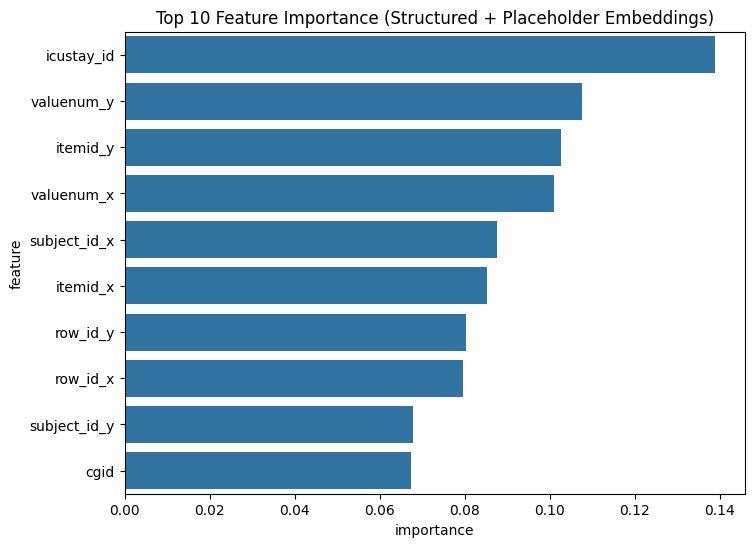

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assume rf is your trained Random Forest
importances = rf.feature_importances_

# Convert to DataFrame
feat_importance_df = pd.DataFrame({
    'feature': combined_cols,   # your structured + embedding column names
    'importance': importances
})

# Sort by importance and take top 10 features
top_features = feat_importance_df.sort_values(by='importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=top_features)
plt.title("Top 10 Feature Importance (Structured + Placeholder Embeddings)")
plt.show()